In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import os

# =========================
#Project Paths
# =========================
PROJECT_DIR = Path("/content/drive/MyDrive/Calorify")

RAW_DATA_DIR = PROJECT_DIR / "dataset"

PHASE1_DIR = PROJECT_DIR / "phase1_clean"

SPLIT_DATA_DIR = PHASE1_DIR / "data" / "split"
METADATA_DIR = PHASE1_DIR / "metadata"
RESULTS_DIR = PHASE1_DIR / "results"
MODELS_DIR = PHASE1_DIR / "models"

for folder in [SPLIT_DATA_DIR, METADATA_DIR, RESULTS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

EXPECTED_CLASSES = [
    "burger",
    "pizza",
    "fries",
    "pasta",
    "rice",
    "chicken",
    "salad",
    "sandwich",
    "sushi",
    "steak"
]

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DATA_DIR)
print("Phase 1 output directory:", PHASE1_DIR)

print("\nChecking class folders...\n")

for class_name in EXPECTED_CLASSES:
    class_dir = RAW_DATA_DIR / class_name

    if class_dir.exists():
        image_count = len([
            f for f in class_dir.iterdir()
            if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
        ])
        print(f"{class_name:10s} -> Found | Images: {image_count}")
    else:
        print(f"{class_name:10s} -> Missing folder")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/Calorify
Raw data directory: /content/drive/MyDrive/Calorify/dataset
Phase 1 output directory: /content/drive/MyDrive/Calorify/phase1_clean

Checking class folders...

burger     -> Found | Images: 576
pizza      -> Found | Images: 1170
fries      -> Found | Images: 585
pasta      -> Found | Images: 720
rice       -> Found | Images: 437
chicken    -> Found | Images: 610
salad      -> Found | Images: 597
sandwich   -> Found | Images: 571
sushi      -> Found | Images: 449
steak      -> Found | Images: 1542


In [ ]:
from pathlib import Path
from PIL import Image
import pandas as pd
import os

# =========================
# Image Cleaning / Validation
# =========================

VALID_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp"]

records = []
failed_records = []

print("Starting image validation...\n")

for class_name in EXPECTED_CLASSES:
    class_dir = RAW_DATA_DIR / class_name

    if not class_dir.exists():
        print(f"Skipping missing class folder: {class_name}")
        continue

    image_files = [
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
    ]

    print(f"Checking {class_name}: {len(image_files)} images")

    for img_path in image_files:
        record = {
            "image_path": str(img_path),
            "file_name": img_path.name,
            "class_name": class_name,
            "extension": img_path.suffix.lower(),
            "file_size_kb": round(img_path.stat().st_size / 1024, 2),
            "width": None,
            "height": None,
            "mode": None,
            "format": None,
            "is_valid": False,
            "error_message": ""
        }

        try:
            # Open image and check basic properties
            with Image.open(img_path) as img:
                record["width"] = img.width
                record["height"] = img.height
                record["mode"] = img.mode
                record["format"] = img.format

                # Convert to RGB to make sure it can be used later
                img.convert("RGB")

                # Basic dimension check
                if img.width < 50 or img.height < 50:
                    raise ValueError("Image dimensions are too small")

                record["is_valid"] = True

        except Exception as e:
            record["is_valid"] = False
            record["error_message"] = str(e)
            failed_records.append(record.copy())

        records.append(record)

# Convert to DataFrames
metadata_df = pd.DataFrame(records)
clean_df = metadata_df[metadata_df["is_valid"] == True].copy()
failed_df = metadata_df[metadata_df["is_valid"] == False].copy()

# Save files
metadata_path = METADATA_DIR / "image_metadata.csv"
clean_path = METADATA_DIR / "image_metadata_clean.csv"
failed_path = METADATA_DIR / "failed_cleaning_images.csv"

metadata_df.to_csv(metadata_path, index=False)
clean_df.to_csv(clean_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("\nCleaning completed.")
print(f"Total images checked: {len(metadata_df)}")
print(f"Valid images: {len(clean_df)}")
print(f"Failed images: {len(failed_df)}")

print("\nSaved files:")
print(metadata_path)
print(clean_path)
print(failed_path)

print("\nValid images per class:")
display(clean_df["class_name"].value_counts().sort_index().reset_index().rename(
    columns={"index": "class_name", "class_name": "valid_images"}
))

if len(failed_df) > 0:
    print("\nFailed images sample:")
    display(failed_df.head())
else:
    print("\nNo failed images found.")

Starting image validation...

Checking burger: 576 images
Checking pizza: 1170 images
Checking fries: 585 images


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Checking pasta: 720 images
Checking rice: 437 images
Checking chicken: 610 images
Checking salad: 597 images
Checking sandwich: 571 images
Checking sushi: 449 images
Checking steak: 1542 images

Cleaning completed.
Total images checked: 7257
Valid images: 7099
Failed images: 158

Saved files:
/content/drive/MyDrive/Calorify/phase1_clean/metadata/image_metadata.csv
/content/drive/MyDrive/Calorify/phase1_clean/metadata/image_metadata_clean.csv
/content/drive/MyDrive/Calorify/phase1_clean/metadata/failed_cleaning_images.csv

Valid images per class:


,valid_images,count
0,burger,576
1,chicken,592
2,fries,585
3,pasta,674
4,pizza,1164
5,rice,430
6,salad,564
7,sandwich,569
8,steak,1499
9,sushi,446



Failed images sample:


,image_path,file_name,class_name,extension,file_size_kb,width,height,mode,format,is_valid,error_message
1494,/content/drive/MyDrive/Calorify/dataset/pizza/...,1077.jpg,pizza,.jpg,0.00,NaN,NaN,None,None,False,cannot identify image file '/content/drive/MyD...
1497,/content/drive/MyDrive/Calorify/dataset/pizza/...,1080.jpg,pizza,.jpg,0.00,NaN,NaN,None,None,False,cannot identify image file '/content/drive/MyD...
1529,/content/drive/MyDrive/Calorify/dataset/pizza/...,1113.jpg,pizza,.jpg,4.45,NaN,NaN,None,None,False,cannot identify image file '/content/drive/MyD...
1541,/content/drive/MyDrive/Calorify/dataset/pizza/...,1124.jpg,pizza,.jpg,47.62,NaN,NaN,None,None,False,cannot identify image file '/content/drive/MyD...
1545,/content/drive/MyDrive/Calorify/dataset/pizza/...,1128.jpg,pizza,.jpg,47.62,NaN,NaN,None,None,False,cannot identify image file '/content/drive/MyD...


In [ ]:
import shutil
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# =========================
# Balanced Dataset + Train/Val/Test Split
# =========================

SEED = 42
MAX_IMAGES_PER_CLASS = 500

# Load clean metadata
clean_metadata_path = METADATA_DIR / "image_metadata_clean.csv"
clean_df = pd.read_csv(clean_metadata_path)

print("Clean metadata loaded:", clean_df.shape)

# Create balanced metadata
balanced_parts = []

for class_name in EXPECTED_CLASSES:
    class_df = clean_df[clean_df["class_name"] == class_name].copy()

    # Shuffle each class
    class_df = class_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    # Cap large classes
    if len(class_df) > MAX_IMAGES_PER_CLASS:
        class_df = class_df.iloc[:MAX_IMAGES_PER_CLASS].copy()

    balanced_parts.append(class_df)

balanced_df = pd.concat(balanced_parts, ignore_index=True)

# Save balanced metadata
balanced_metadata_path = METADATA_DIR / "image_metadata_balanced.csv"
balanced_df.to_csv(balanced_metadata_path, index=False)

print("\nBalanced dataset created.")
print("Total balanced images:", len(balanced_df))
print("\nBalanced images per class:")
display(
    balanced_df["class_name"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "class_name", "class_name": "count"})
)

# =========================
# Create train / val / test split
# =========================

train_parts = []
val_parts = []
test_parts = []

for class_name in EXPECTED_CLASSES:
    class_df = balanced_df[balanced_df["class_name"] == class_name].copy()

    # First split: 70% train, 30% temp
    train_df, temp_df = train_test_split(
        class_df,
        test_size=0.30,
        random_state=SEED,
        shuffle=True
    )

    # Second split: temp into 15% val and 15% test
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        shuffle=True
    )

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    train_parts.append(train_df)
    val_parts.append(val_df)
    test_parts.append(test_df)

split_df = pd.concat(train_parts + val_parts + test_parts, ignore_index=True)

# Save split metadata
split_metadata_path = METADATA_DIR / "image_split_metadata.csv"
split_df.to_csv(split_metadata_path, index=False)

print("\nSplit metadata saved:")
print(split_metadata_path)

# =========================
# Copy images into split folders
# =========================

# Remove old split folder if exists
if SPLIT_DATA_DIR.exists():
    shutil.rmtree(SPLIT_DATA_DIR)

# Create split/class directories
for split_name in ["train", "val", "test"]:
    for class_name in EXPECTED_CLASSES:
        (SPLIT_DATA_DIR / split_name / class_name).mkdir(parents=True, exist_ok=True)

print("\nCopying images to split folders...")

for _, row in split_df.iterrows():
    src_path = Path(row["image_path"])
    split_name = row["split"]
    class_name = row["class_name"]

    dst_path = SPLIT_DATA_DIR / split_name / class_name / src_path.name

    # In case two files have the same name within same class/split, keep it safe
    if dst_path.exists():
        dst_path = SPLIT_DATA_DIR / split_name / class_name / f"{src_path.stem}_{row.name}{src_path.suffix}"

    shutil.copy2(src_path, dst_path)

print("Copying completed.")

# =========================
# Create split summary
# =========================

summary_df = (
    split_df
    .groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure columns exist
for col in ["train", "val", "test"]:
    if col not in summary_df.columns:
        summary_df[col] = 0

summary_df["total"] = summary_df["train"] + summary_df["val"] + summary_df["test"]
summary_df = summary_df[["class_name", "total", "train", "val", "test"]]

summary_path = METADATA_DIR / "image_split_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\nImage split summary saved:")
print(summary_path)

print("\nFinal split summary:")
display(summary_df)

print("\nSplit data directory:")
print(SPLIT_DATA_DIR)

Clean metadata loaded: (7099, 11)

Balanced dataset created.
Total balanced images: 4876

Balanced images per class:


,count,count
0,burger,500
1,chicken,500
2,fries,500
3,pasta,500
4,pizza,500
5,rice,430
6,salad,500
7,sandwich,500
8,steak,500
9,sushi,446



Split metadata saved:
/content/drive/MyDrive/Calorify/phase1_clean/metadata/image_split_metadata.csv

Copying images to split folders...
Copying completed.

Image split summary saved:
/content/drive/MyDrive/Calorify/phase1_clean/metadata/image_split_summary.csv

Final split summary:


split,class_name,total,train,val,test
0,burger,500,350,75,75
1,chicken,500,350,75,75
2,fries,500,350,75,75
3,pasta,500,350,75,75
4,pizza,500,350,75,75
5,rice,430,301,64,65
6,salad,500,350,75,75
7,sandwich,500,350,75,75
8,steak,500,350,75,75
9,sushi,446,312,67,67



Split data directory:
/content/drive/MyDrive/Calorify/phase1_clean/data/split


In [ ]:
from pathlib import Path
import pandas as pd

VALID_EXTENSIONS = [".jpg", ".jpeg", ".png", ".webp"]

print("Checking actual files inside split folders...\n")
print("SPLIT_DATA_DIR:", SPLIT_DATA_DIR)

rows = []

for split_name in ["train", "val", "test"]:
    for class_name in EXPECTED_CLASSES:
        folder = SPLIT_DATA_DIR / split_name / class_name

        if folder.exists():
            image_count = len([
                f for f in folder.iterdir()
                if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
            ])
        else:
            image_count = -1

        rows.append({
            "split": split_name,
            "class_name": class_name,
            "actual_files": image_count
        })

actual_counts_df = pd.DataFrame(rows)

display(actual_counts_df.pivot(index="class_name", columns="split", values="actual_files"))

print("\nChecking saved split summary CSV...\n")

summary_path = METADATA_DIR / "image_split_summary.csv"

if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display(summary_df)
else:
    print("image_split_summary.csv not found")

Checking actual files inside split folders...

SPLIT_DATA_DIR: /content/drive/MyDrive/Calorify/phase1_clean/data/split


split,test,train,val
class_name,,,
burger,75,350,75
chicken,75,350,75
fries,75,350,75
pasta,75,350,75
pizza,75,350,75
rice,65,301,64
salad,75,350,75
sandwich,75,350,75
steak,75,350,75



Checking saved split summary CSV...



,class_name,total,train,val,test
0,burger,500,350,75,75
1,chicken,500,350,75,75
2,fries,500,350,75,75
3,pasta,500,350,75,75
4,pizza,500,350,75,75
5,rice,430,301,64,65
6,salad,500,350,75,75
7,sandwich,500,350,75,75
8,steak,500,350,75,75
9,sushi,446,312,67,67


In [ ]:
import tensorflow as tf
import json
from pathlib import Path

# =========================
# TensorFlow Data Loading
# =========================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = SPLIT_DATA_DIR / "train"
val_dir = SPLIT_DATA_DIR / "val"
test_dir = SPLIT_DATA_DIR / "test"

print("Train directory:", train_dir)
print("Val directory:", val_dir)
print("Test directory:", test_dir)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=EXPECTED_CLASSES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=EXPECTED_CLASSES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=EXPECTED_CLASSES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("\nClass names:")
print(class_names)

# Save class names
class_names_path = METADATA_DIR / "class_names.json"

with open(class_names_path, "w") as f:
    json.dump(class_names, f, indent=4)

print("\nClass names saved to:")
print(class_names_path)

# Improve performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("\nDatasets loaded successfully.")

Train directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/train
Val directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/val
Test directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/test
Found 3413 files belonging to 10 classes.
Found 731 files belonging to 10 classes.
Found 732 files belonging to 10 classes.

Class names:
['burger', 'pizza', 'fries', 'pasta', 'rice', 'chicken', 'salad', 'sandwich', 'sushi', 'steak']

Class names saved to:
/content/drive/MyDrive/Calorify/phase1_clean/metadata/class_names.json

Datasets loaded successfully.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Visual Check: Show Sample Images
# =========================

plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)

        img = images[i].numpy().astype("uint8")
        label_index = np.argmax(labels[i].numpy())
        label_name = class_names[label_index]

        plt.imshow(img)
        plt.title(label_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Output hidden; open in https://colab.research.google.com to view.

Data augmentation pipeline created successfully.


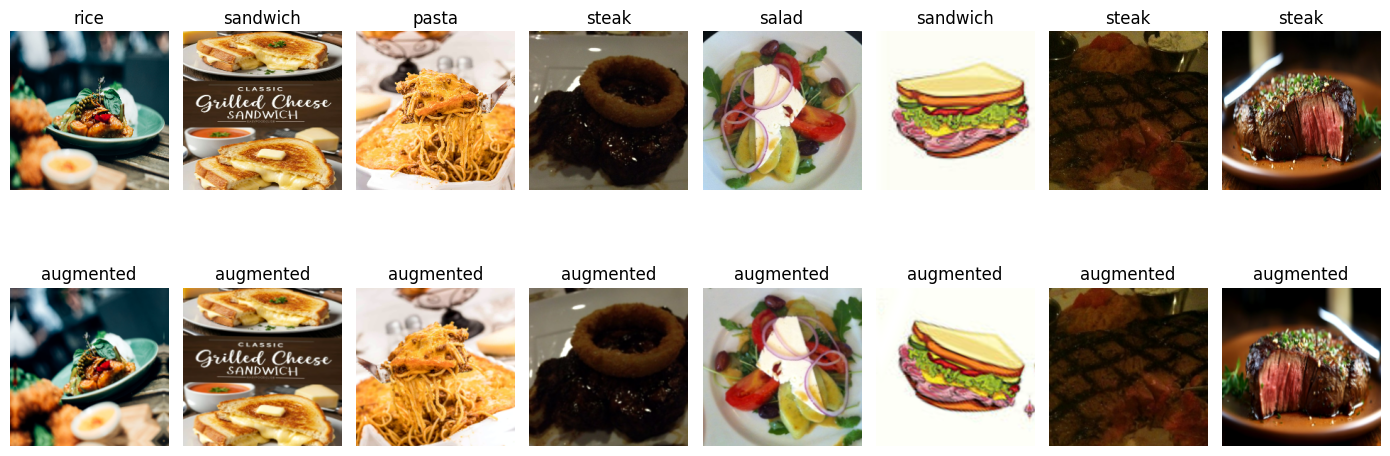

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data Augmentation Layer
# =========================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

print("Data augmentation pipeline created successfully.")

# =========================
# Preview Augmented Images
# =========================

for images, labels in train_ds.take(1):
    sample_images = images[:8]
    sample_labels = labels[:8]
    augmented_images = data_augmentation(sample_images, training=True)

plt.figure(figsize=(14, 6))

for i in range(8):
    label_index = np.argmax(sample_labels[i].numpy())
    label_name = class_names[label_index]

    # Original image
    ax = plt.subplot(2, 8, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    plt.title(label_name)
    plt.axis("off")

    # Augmented image
    ax = plt.subplot(2, 8, i + 9)
    aug_img = augmented_images[i].numpy()
    aug_img = np.clip(aug_img, 0, 255).astype("uint8")
    plt.imshow(aug_img)
    plt.title("augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

# =========================
# Compute Class Weights
# =========================

split_metadata_path = METADATA_DIR / "image_split_metadata.csv"
split_df = pd.read_csv(split_metadata_path)

# Use train split only
train_split_df = split_df[split_df["split"] == "train"].copy()

# Convert class names to numeric indices using the same order as TensorFlow
class_to_index = {class_name: idx for idx, class_name in enumerate(class_names)}

y_train_indices = train_split_df["class_name"].map(class_to_index).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=y_train_indices
)

class_weight = {
    idx: float(weight)
    for idx, weight in enumerate(weights)
}

class_weight_df = pd.DataFrame({
    "class_index": list(class_weight.keys()),
    "class_name": class_names,
    "train_count": [
        train_split_df[train_split_df["class_name"] == class_name].shape[0]
        for class_name in class_names
    ],
    "class_weight": list(class_weight.values())
})

print("Class weights created successfully:")
display(class_weight_df)

print("\nclass_weight dictionary:")
print(class_weight)

Class weights created successfully:


,class_index,class_name,train_count,class_weight
0,0,burger,350,0.975143
1,1,pizza,350,0.975143
2,2,fries,350,0.975143
3,3,pasta,350,0.975143
4,4,rice,301,1.133887
5,5,chicken,350,0.975143
6,6,salad,350,0.975143
7,7,sandwich,350,0.975143
8,8,sushi,312,1.093910
9,9,steak,350,0.975143



class_weight dictionary:
{0: 0.9751428571428571, 1: 0.9751428571428571, 2: 0.9751428571428571, 3: 0.9751428571428571, 4: 1.1338870431893688, 5: 0.9751428571428571, 6: 0.9751428571428571, 7: 0.9751428571428571, 8: 1.0939102564102565, 9: 0.9751428571428571}


In [ ]:
# =========================
# Save Class Weights
# =========================

class_weight_path = METADATA_DIR / "class_weights.csv"
class_weight_df.to_csv(class_weight_path, index=False)

print("Class weights saved to:")
print(class_weight_path)

display(class_weight_df)

Class weights saved to:
/content/drive/MyDrive/Calorify/phase1_clean/metadata/class_weights.csv


,class_index,class_name,train_count,class_weight
0,0,burger,350,0.975143
1,1,pizza,350,0.975143
2,2,fries,350,0.975143
3,3,pasta,350,0.975143
4,4,rice,301,1.133887
5,5,chicken,350,0.975143
6,6,salad,350,0.975143
7,7,sandwich,350,0.975143
8,8,sushi,312,1.093910
9,9,steak,350,0.975143


Data augmentation pipeline created successfully.


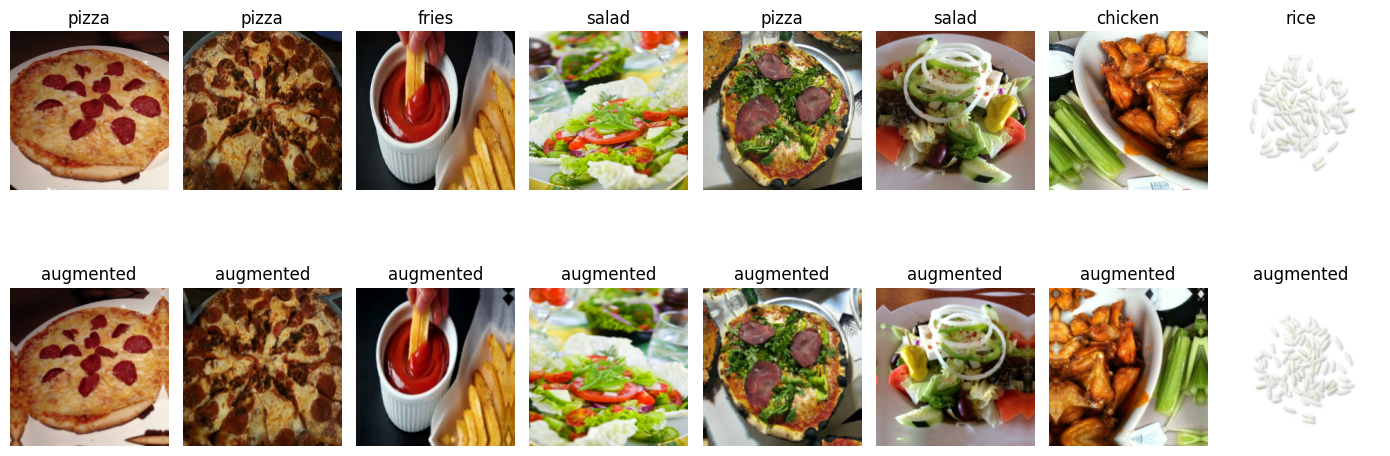

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data Augmentation Layer
# =========================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

print("Data augmentation pipeline created successfully.")

# =========================
# Preview Augmented Images
# =========================

for images, labels in train_ds.take(1):
    sample_images = images[:8]
    sample_labels = labels[:8]
    augmented_images = data_augmentation(sample_images, training=True)

plt.figure(figsize=(14, 6))

for i in range(8):
    label_index = np.argmax(sample_labels[i].numpy())
    label_name = class_names[label_index]

    # Original image
    ax = plt.subplot(2, 8, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    plt.title(label_name)
    plt.axis("off")

    # Augmented image
    ax = plt.subplot(2, 8, i + 9)
    aug_img = augmented_images[i].numpy()
    aug_img = np.clip(aug_img, 0, 255).astype("uint8")
    plt.imshow(aug_img)
    plt.title("augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# =========================
# Custom CNN From Scratch
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
from pathlib import Path
import gc

# Clear old model/session from memory
tf.keras.backend.clear_session()
gc.collect()

# =========================
# CNN Config
# =========================

NUM_CLASSES = len(class_names)
EPOCHS_CNN = 20
LEARNING_RATE_CNN = 1e-4

CNN_MODEL_PATH = MODELS_DIR / "custom_cnn_from_scratch.keras"
CNN_HISTORY_PATH = RESULTS_DIR / "custom_cnn_history.csv"

print("Starting CNN training setup...")
print("Number of classes:", NUM_CLASSES)
print("CNN model will be saved to:", CNN_MODEL_PATH)

# =========================
# Data Augmentation
# =========================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

# =========================
# Build Custom CNN Model
# =========================

def build_custom_cnn(input_shape=(224, 224, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape, name="input_image")

    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255, name="rescaling")(x)

    # CNN Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # CNN Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # CNN Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # CNN Block 4
    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="food_class_output")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Custom_CNN_From_Scratch")
    return model

cnn_model = build_custom_cnn(num_classes=NUM_CLASSES)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_CNN),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Starting CNN training setup...
Number of classes: 10
CNN model will be saved to: /content/drive/MyDrive/Calorify/phase1_clean/models/custom_cnn_from_scratch.keras


Model: "Custom_CNN_From_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ food_class_output (Dense)       │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 490,314 (1.87 MB)

 Trainable params: 489,354 (1.87 MB)

 Non-trainable params: 960 (3.75 KB)

In [37]:
import pandas as pd
import tensorflow as tf

# =========================
# Custom CNN Callbacks
# =========================

cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CNN_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# =========================
# Train Custom CNN From Scratch
# =========================

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=cnn_callbacks,
    class_weight=class_weight
)

# =========================
# Save Training History
# =========================

cnn_history_df = pd.DataFrame(cnn_history.history)
cnn_history_df.to_csv(CNN_HISTORY_PATH, index=False)

print("CNN training completed.")
print("CNN model saved to:")
print(CNN_MODEL_PATH)

print("\nCNN history saved to:")
print(CNN_HISTORY_PATH)

display(cnn_history_df)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.1650 - loss: 2.4325
Epoch 1: val_loss improved from None to 2.31495, saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/custom_cnn_from_scratch.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/custom_cnn_from_scratch.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 400ms/step - accuracy: 0.1992 - loss: 2.2734 - val_accuracy: 0.0876 - val_loss: 2.3149 - learning_rate: 1.0000e-04
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.2599 - loss: 2.0635
Epoch 2: val_loss did not improve from 2.31495
107/107 ━━━━━━━━━━━━━━━━━━━━ 42s 388ms/step - accuracy: 0.2716 - loss: 2.0445 - val_accuracy: 0.1040 - val_loss: 2.3365 - learning_rate: 1.0000e-04
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.3069 - loss: 1.9603
Epoch 3: val_loss improved from 2.31495 to 2.29221, saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/custom_cn

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.199238,2.273376,0.087551,2.314946,0.000100
1,0.271609,2.044516,0.103967,2.336515,0.000100
2,0.314386,1.953794,0.136799,2.292215,0.000100
3,0.341928,1.893580,0.202462,2.100307,0.000100
4,0.362731,1.837111,0.362517,1.859314,0.000100
5,0.377967,1.792238,0.393981,1.744173,0.000100
6,0.392030,1.739795,0.380301,1.771150,0.000100
7,0.409610,1.702714,0.433653,1.676269,0.000100
8,0.426604,1.666160,0.462380,1.595596,0.000100
9,0.449165,1.611679,0.436389,1.668942,0.000100


In [38]:
import tensorflow as tf

best_cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)

test_loss, test_accuracy = best_cnn_model.evaluate(test_ds)

print("Custom CNN Test Loss:", test_loss)
print("Custom CNN Test Accuracy:", test_accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step - accuracy: 0.5055 - loss: 1.5211
Custom CNN Test Loss: 1.5210717916488647
Custom CNN Test Accuracy: 0.505464494228363


Training history loaded from:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.199238,2.273376,0.087551,2.314946,0.000100
1,0.271609,2.044516,0.103967,2.336515,0.000100
2,0.314386,1.953794,0.136799,2.292215,0.000100
3,0.341928,1.893580,0.202462,2.100307,0.000100
4,0.362731,1.837111,0.362517,1.859314,0.000100
5,0.377967,1.792238,0.393981,1.744173,0.000100
6,0.392030,1.739795,0.380301,1.771150,0.000100
7,0.409610,1.702714,0.433653,1.676269,0.000100
8,0.426604,1.666160,0.462380,1.595596,0.000100
9,0.449165,1.611679,0.436389,1.668942,0.000100


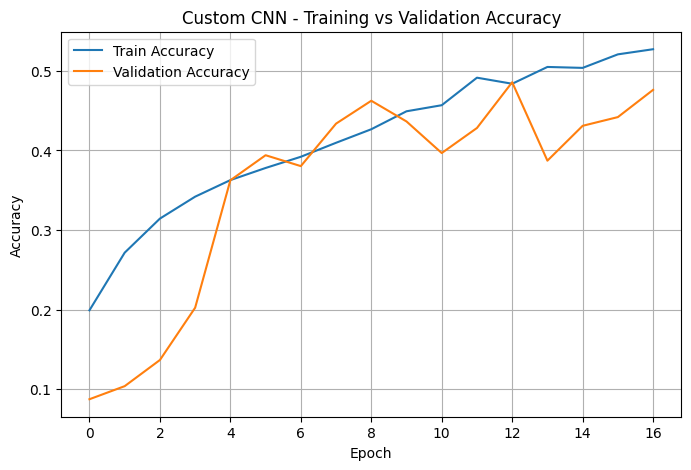

Accuracy curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_accuracy_curve.png


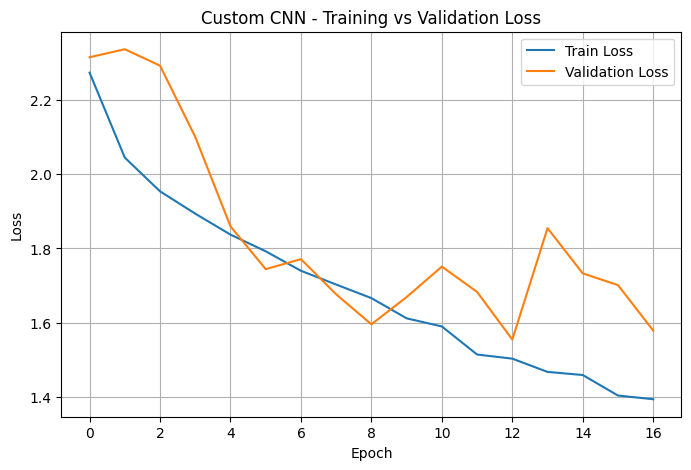

Loss curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_loss_curve.png


In [39]:
# =========================
# Custom CNN Training Curves
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load training history
history_df = pd.read_csv(CNN_HISTORY_PATH)

print("Training history loaded from:")
print(CNN_HISTORY_PATH)

display(history_df)

# =========================
# Accuracy Curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_curve_path = RESULTS_DIR / "custom_cnn_accuracy_curve.png"
plt.savefig(accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved to:")
print(accuracy_curve_path)

# =========================
# Loss Curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Custom CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_curve_path = RESULTS_DIR / "custom_cnn_loss_curve.png"
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved to:")
print(loss_curve_path)

Loaded best Custom CNN model from:
/content/drive/MyDrive/Calorify/phase1_clean/models/custom_cnn_from_scratch.keras
Classification report saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_classification_report.csv


,precision,recall,f1-score,support
burger,0.600000,0.600000,0.600000,75.000000
pizza,0.580000,0.386667,0.464000,75.000000
fries,0.808511,0.506667,0.622951,75.000000
pasta,0.463415,0.253333,0.327586,75.000000
rice,0.404040,0.615385,0.487805,65.000000
chicken,0.389610,0.400000,0.394737,75.000000
salad,0.726027,0.706667,0.716216,75.000000
sandwich,0.523810,0.146667,0.229167,75.000000
sushi,0.583333,0.626866,0.604317,67.000000
steak,0.355932,0.840000,0.500000,75.000000


Confusion matrix CSV saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_confusion_matrix.csv


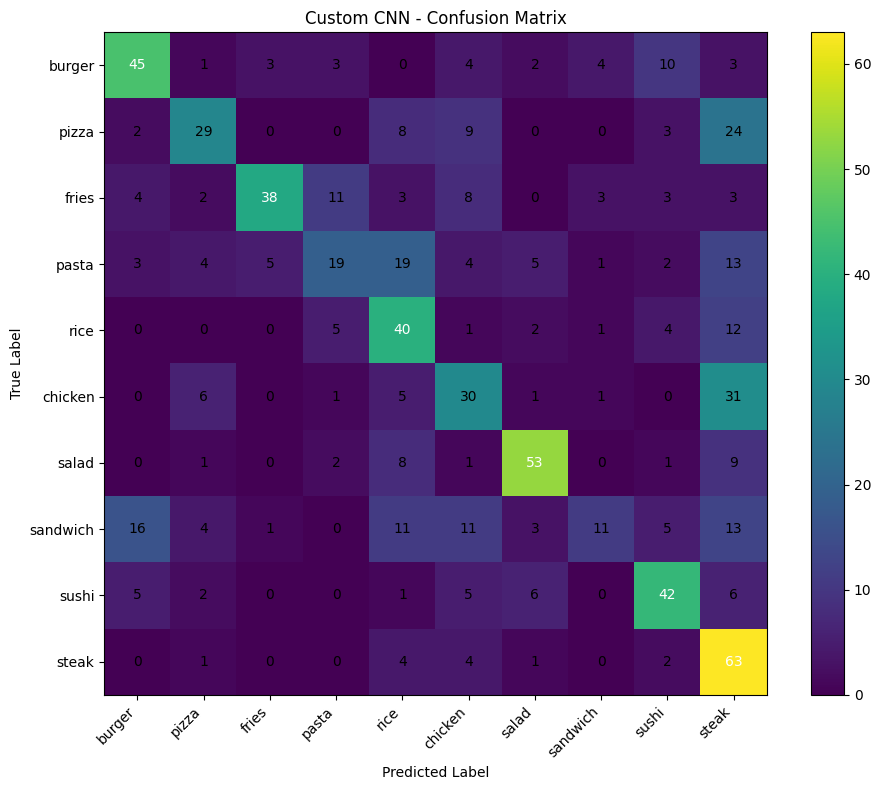

Confusion matrix image saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_confusion_matrix.png


In [40]:
# =========================
# Custom CNN Classification Report + Confusion Matrix
# =========================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

# Load best saved Custom CNN model
best_cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)

print("Loaded best Custom CNN model from:")
print(CNN_MODEL_PATH)

# =========================
# Collect True Labels and Predictions
# =========================

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probabilities = best_cnn_model.predict(images, verbose=0)

    true_indices = np.argmax(labels.numpy(), axis=1)
    pred_indices = np.argmax(probabilities, axis=1)

    y_true.extend(true_indices)
    y_pred.extend(pred_indices)
    y_prob.extend(np.max(probabilities, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# =========================
# Classification Report
# =========================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

cnn_report_path = RESULTS_DIR / "custom_cnn_classification_report.csv"
report_df.to_csv(cnn_report_path)

print("Classification report saved to:")
print(cnn_report_path)

display(report_df)

# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cnn_cm_csv_path = RESULTS_DIR / "custom_cnn_confusion_matrix.csv"
cm_df.to_csv(cnn_cm_csv_path)

print("Confusion matrix CSV saved to:")
print(cnn_cm_csv_path)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Custom CNN - Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside cells
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()

cnn_cm_png_path = RESULTS_DIR / "custom_cnn_confusion_matrix.png"
plt.savefig(cnn_cm_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix image saved to:")
print(cnn_cm_png_path)

Wrong predictions saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_wrong_predictions.csv

Number of wrong predictions: 362
Number of correct predictions: 370


,image_path,true_class,predicted_class,confidence,is_correct
0,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sushi,0.568105,False
1,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sushi,0.185083,False
2,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,pizza,0.534665,False
3,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,chicken,0.455109,False
4,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sushi,0.192054,False
5,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,pasta,0.206075,False
6,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,pasta,0.220718,False
7,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,chicken,0.407135,False
8,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sushi,0.584508,False
9,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sushi,0.189875,False


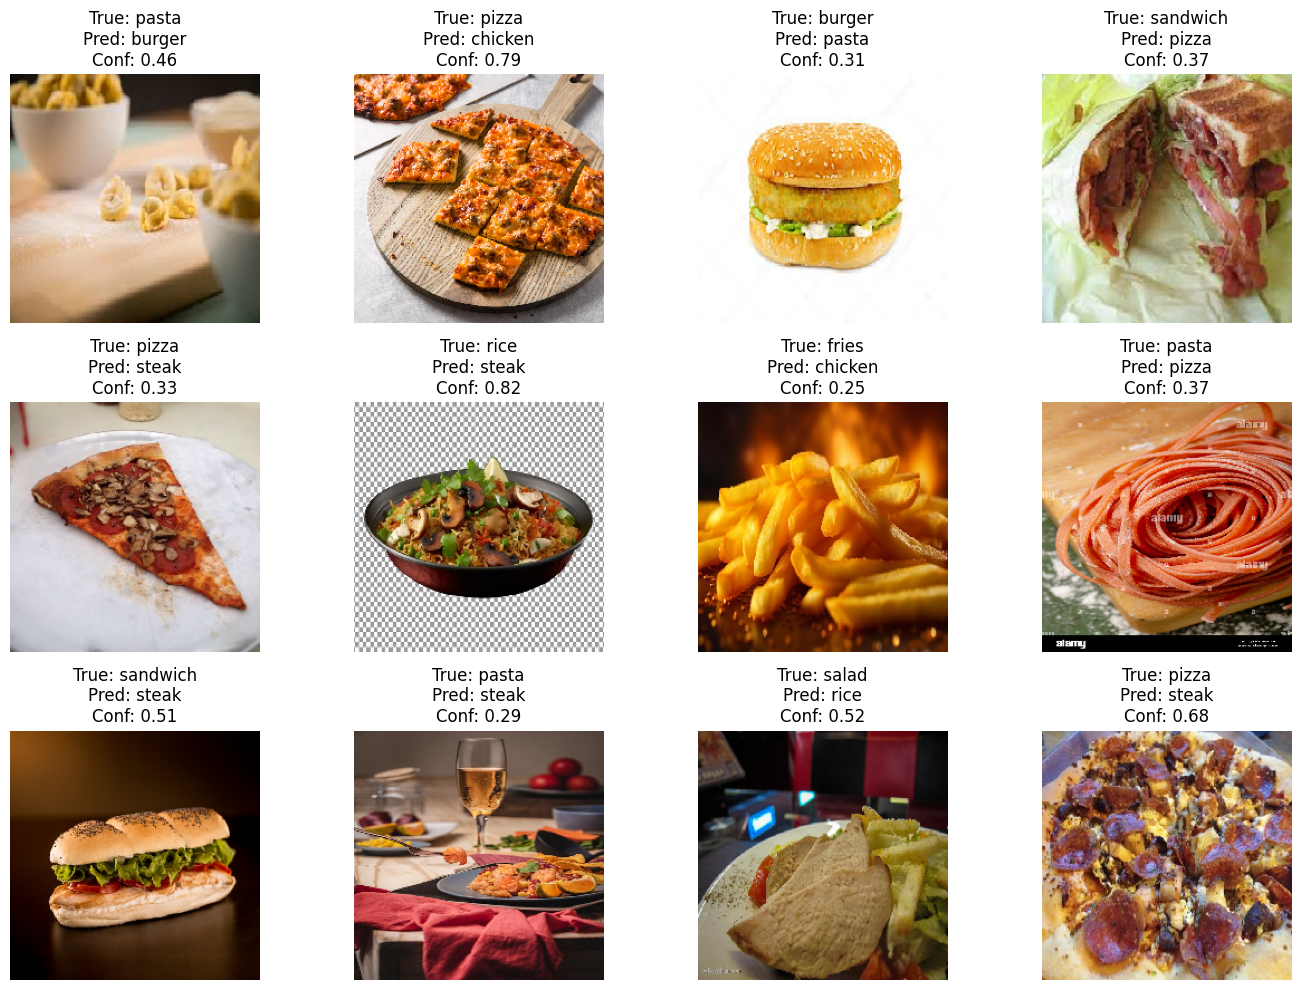

Wrong prediction samples image saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_wrong_prediction_samples.png


In [41]:
# =========================
# Custom CNN Wrong Prediction Samples
# =========================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load best saved model
best_cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)

wrong_records = []
correct_records = []

# Collect file paths from test directory in the same order as test_ds
test_image_paths = []

for class_name in class_names:
    class_dir = test_dir / class_name
    class_files = sorted([
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
    ])
    test_image_paths.extend(class_files)

sample_index = 0

for images, labels in test_ds:
    probabilities = best_cnn_model.predict(images, verbose=0)

    true_indices = np.argmax(labels.numpy(), axis=1)
    pred_indices = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    for i in range(len(images)):
        true_class = class_names[true_indices[i]]
        predicted_class = class_names[pred_indices[i]]
        confidence = float(confidences[i])

        image_path = str(test_image_paths[sample_index]) if sample_index < len(test_image_paths) else ""

        record = {
            "image_path": image_path,
            "true_class": true_class,
            "predicted_class": predicted_class,
            "confidence": confidence,
            "is_correct": true_class == predicted_class
        }

        if true_class == predicted_class:
            correct_records.append(record)
        else:
            wrong_records.append(record)

        sample_index += 1

wrong_df = pd.DataFrame(wrong_records)
correct_df = pd.DataFrame(correct_records)

wrong_predictions_path = RESULTS_DIR / "custom_cnn_wrong_predictions.csv"
wrong_df.to_csv(wrong_predictions_path, index=False)

print("Wrong predictions saved to:")
print(wrong_predictions_path)

print("\nNumber of wrong predictions:", len(wrong_df))
print("Number of correct predictions:", len(correct_df))

display(wrong_df.head(20))

# =========================
# Show Sample Wrong Predictions
# =========================

sample_wrong_df = wrong_df.sample(
    n=min(12, len(wrong_df)),
    random_state=42
).reset_index(drop=True)

plt.figure(figsize=(14, 10))

for i, row in sample_wrong_df.iterrows():
    img_path = row["image_path"]

    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img_array)
    plt.title(
        f"True: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']:.2f}"
    )
    plt.axis("off")

plt.tight_layout()

wrong_samples_path = RESULTS_DIR / "custom_cnn_wrong_prediction_samples.png"
plt.savefig(wrong_samples_path, dpi=300, bbox_inches="tight")
plt.show()

print("Wrong prediction samples image saved to:")
print(wrong_samples_path)

In [42]:
# =========================
# Save Final Custom CNN Summary
# =========================

import pandas as pd
from pathlib import Path

custom_cnn_summary = {
    "model_name": "Custom CNN From Scratch",
    "model_type": "Baseline CNN",
    "model_file": str(CNN_MODEL_PATH),
    "history_file": str(CNN_HISTORY_PATH),
    "test_accuracy": 0.505464494228363,
    "test_loss": 1.5210717916488647,
    "best_validation_accuracy": 0.485636,
    "best_validation_loss": 1.554560,
    "macro_f1_score": 0.494678,
    "weighted_f1_score": 0.493573,
    "correct_predictions": 370,
    "wrong_predictions": 362,
    "status": "Completed",
    "notes": (
        "Custom CNN was used as a baseline model. "
        "The model achieved moderate performance and showed limitations "
        "on visually similar food classes, motivating the use of pretrained transfer learning models."
    )
}

custom_cnn_summary_df = pd.DataFrame([custom_cnn_summary])

summary_csv_path = RESULTS_DIR / "custom_cnn_final_summary.csv"
summary_txt_path = RESULTS_DIR / "custom_cnn_final_summary.txt"

custom_cnn_summary_df.to_csv(summary_csv_path, index=False)

with open(summary_txt_path, "w") as f:
    for key, value in custom_cnn_summary.items():
        f.write(f"{key}: {value}\n")

print("Custom CNN final summary saved to:")
print(summary_csv_path)
print(summary_txt_path)

display(custom_cnn_summary_df)

Custom CNN final summary saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_final_summary.csv
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_final_summary.txt


,model_name,model_type,model_file,history_file,test_accuracy,test_loss,best_validation_accuracy,best_validation_loss,macro_f1_score,weighted_f1_score,correct_predictions,wrong_predictions,status,notes
0,Custom CNN From Scratch,Baseline CNN,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/r...,0.505464,1.521072,0.485636,1.55456,0.494678,0.493573,370,362,Completed,Custom CNN was used as a baseline model. The m...


In [43]:
# =========================
# Save Custom CNN Final Summary Text
# =========================

custom_cnn_summary_text = """
Final Summary — Custom CNN Baseline

In this notebook, the Phase 1 image dataset was prepared and evaluated for the food image classification task. The raw scraped image dataset was cleaned, invalid images were removed, and the remaining valid images were organized into train, validation, and test splits.

A balanced sampling strategy was applied by limiting overrepresented classes to a maximum of 500 images per class. The final split was loaded using TensorFlow with image size 224×224 and batch size 32. Class weights were also calculated to reduce the effect of class imbalance, especially for smaller classes such as rice and sushi.

A Custom CNN model was then trained from scratch as the baseline model for Phase 1. The model used convolutional layers, batch normalization, max pooling, global average pooling, dropout, and a softmax classification output for the 10 food classes.

The Custom CNN achieved:
- Test Accuracy: 50.55%
- Test Loss: 1.5211
- Macro F1-score: 49.47%
- Weighted F1-score: 49.36%

The model performed relatively better on classes such as salad, fries, sushi, and burger. However, it struggled with visually similar or noisy classes such as sandwich, pasta, chicken, and steak.

The confusion matrix and wrong prediction samples showed that many errors were caused by visually ambiguous images, mixed dishes, low-quality scraped images, watermarks, unusual cropping, and overlapping food patterns. Common confusion cases included burger vs sandwich, chicken vs steak, rice vs salad, and pizza vs chicken/steak.

Overall, the Custom CNN achieved a useful baseline result. However, its limitations show that training a CNN from scratch is not enough for this noisy scraped food dataset. Therefore, pretrained transfer learning models such as MobileNetV2, EfficientNetB0, ResNet50, and Vision Transformer will be tested next to improve visual feature extraction and classification performance.
"""

summary_text_path = RESULTS_DIR / "custom_cnn_final_written_summary.txt"

with open(summary_text_path, "w", encoding="utf-8") as f:
    f.write(custom_cnn_summary_text)

print("Custom CNN written summary saved to:")
print(summary_text_path)

Custom CNN written summary saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_final_written_summary.txt
